In [93]:
# importing required libraries
import numpy as np
import pandas as pd
import nltk

In [94]:
# we will use VADER for this project
# VADER is Valence Aware Dictionary and sEntiment Reasoner
# for sentiment Analysis
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon') # downloading the lexicon

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [95]:
# testing
# for sanity check
test_sentence = "I love cakes"
sia = SentimentIntensityAnalyzer()
sia.polarity_scores(test_sentence)

{'neg': 0.0, 'neu': 0.192, 'pos': 0.808, 'compound': 0.6369}

In [96]:
import json
# now loading the dataset
# in this project using Kaggle's News Category Dataset
data = []

with open("/content/News_Category_Dataset_v3.json", "r") as f:
    for line in f:
        try:
            # Each line is expected to be a JSON object
            data.append(json.loads(line.strip()))
        except json.JSONDecodeError as e:
            print(f"Skipping malformed JSON line: {line.strip()} - Error: {e}")
            continue

df = pd.DataFrame(data)

Skipping malformed JSON line: Asking If He Has Bad Hair'", "authors": "Sam Levine", "link": "https://www.huffingtonpost.com/entry/elizabeth-warren-donald-trump_us_57250a50e4b01a5ebde5d1b3", "short_description": "\"He wears the sexism out front for everyone to see.\u201d", "date": "2016-04-30"} - Error: Expecting value: line 1 column 1 (char 0)


In [97]:
# now printing first 5 rows of the df
df.head(5)

,category,headline,authors,link,short_description,date
0,POLITICS,John Kasich Confronted Over GOP’s Anti-Gay Sta...,Mollie Reilly,https://www.huffingtonpost.com/entry/john-kasi...,Things got heated when the Republican presiden...,2016-04-30
1,GREEN,Texas Floods Kill Grandmother And 4 Grandchildren,,https://www.huffingtonpost.com/entry/texas-flo...,There were also numerous tornadoes from the st...,2016-04-30
2,SPORTS,Marlins Dee Gordon Suspended For 80 Games For ...,,https://www.huffingtonpost.com/entry/dee-gordo...,He will be ineligible for post season play sh...,2016-04-30
3,CRIME,Louisiana Prisoner Freed After 41 Years Of Unc...,,https://www.huffingtonpost.com/entry/louisiana...,"At 16, Tyler was the youngest person on Louisi...",2016-04-30
4,COMEDY,Bill Maher Reveals '25 Things You Don't Know' ...,Lee Moran,https://www.huffingtonpost.com/entry/bill-mahe...,"""I'm the only candidate who uses a typewriter ...",2016-04-30


In [98]:
# shape of the dataset
print(df.shape)

(140854, 6)


In [99]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140854 entries, 0 to 140853
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   category           140854 non-null  object
 1   headline           140854 non-null  object
 2   authors            140854 non-null  object
 3   link               140854 non-null  object
 4   short_description  140854 non-null  object
 5   date               140854 non-null  object
dtypes: object(6)
memory usage: 6.4+ MB


In [100]:
# ignoring other columns
# irrelevant
# dropping them
df = df.drop(columns=['category','authors','link','date'])
df.head() # checking

,headline,short_description
0,John Kasich Confronted Over GOP’s Anti-Gay Sta...,Things got heated when the Republican presiden...
1,Texas Floods Kill Grandmother And 4 Grandchildren,There were also numerous tornadoes from the st...
2,Marlins Dee Gordon Suspended For 80 Games For ...,He will be ineligible for post season play sh...
3,Louisiana Prisoner Freed After 41 Years Of Unc...,"At 16, Tyler was the youngest person on Louisi..."
4,Bill Maher Reveals '25 Things You Don't Know' ...,"""I'm the only candidate who uses a typewriter ..."


In [101]:
# creating a new column
# by merging headline and short description
df['text'] = df['headline'] + '. ' + df['short_description']
df['text'] = df['text'].str.strip()
df.head()

,headline,short_description,text
0,John Kasich Confronted Over GOP’s Anti-Gay Sta...,Things got heated when the Republican presiden...,John Kasich Confronted Over GOP’s Anti-Gay Sta...
1,Texas Floods Kill Grandmother And 4 Grandchildren,There were also numerous tornadoes from the st...,Texas Floods Kill Grandmother And 4 Grandchild...
2,Marlins Dee Gordon Suspended For 80 Games For ...,He will be ineligible for post season play sh...,Marlins Dee Gordon Suspended For 80 Games For ...
3,Louisiana Prisoner Freed After 41 Years Of Unc...,"At 16, Tyler was the youngest person on Louisi...",Louisiana Prisoner Freed After 41 Years Of Unc...
4,Bill Maher Reveals '25 Things You Don't Know' ...,"""I'm the only candidate who uses a typewriter ...",Bill Maher Reveals '25 Things You Don't Know' ...


In [102]:
# checking few rows of new column
for i in range(2):
  print(df['text'][i])

John Kasich Confronted Over GOP’s Anti-Gay Stance During San Francisco Town Hall. Things got heated when the Republican presidential candidate was pressed on his party's history of discrimination.
Texas Floods Kill Grandmother And 4 Grandchildren. There were also numerous tornadoes from the storm system in Texas and Oklahoma.


In [103]:
# dropping the other two columns
df = df.drop(columns=['headline','short_description'])
df.head(5)

,text
0,John Kasich Confronted Over GOP’s Anti-Gay Sta...
1,Texas Floods Kill Grandmother And 4 Grandchild...
2,Marlins Dee Gordon Suspended For 80 Games For ...
3,Louisiana Prisoner Freed After 41 Years Of Unc...
4,Bill Maher Reveals '25 Things You Don't Know' ...


In [104]:
# now we will use punkt tokenizer
# sentence tokenizer
# downloading it
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [105]:
# importing library
from nltk.tokenize import sent_tokenize

# creating a new column
# stores tokens
df['sentences'] = df['text'].apply(sent_tokenize)
df.head()

,text,sentences
0,John Kasich Confronted Over GOP’s Anti-Gay Sta...,[John Kasich Confronted Over GOP’s Anti-Gay St...
1,Texas Floods Kill Grandmother And 4 Grandchild...,[Texas Floods Kill Grandmother And 4 Grandchil...
2,Marlins Dee Gordon Suspended For 80 Games For ...,[Marlins Dee Gordon Suspended For 80 Games For...
3,Louisiana Prisoner Freed After 41 Years Of Unc...,[Louisiana Prisoner Freed After 41 Years Of Un...
4,Bill Maher Reveals '25 Things You Don't Know' ...,[Bill Maher Reveals '25 Things You Don't Know'...


In [106]:
# sanity check
df['sentences'][0]

['John Kasich Confronted Over GOP’s Anti-Gay Stance During San Francisco Town Hall.',
 "Things got heated when the Republican presidential candidate was pressed on his party's history of discrimination."]

In [107]:
# now writing own function
# to see negativity dominance scoring
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def negativity_dominance_scoring(sent_arr):
  compound = []
  neg = []
  n = len(sent_arr)

  for sent in sent_arr:
    scores = sia.polarity_scores(sent)
    compound_score = scores['compound']
    neg_score = scores['neg']

    # if condintion to find out where neg>pos
    if neg_score > scores['pos']:
      neg.append(neg_score)

    compound.append(compound_score)

  avg_compound = sum(compound) / len(compound)

  if len(neg)!=0:
    max_neg = max(neg)
  else:
    max_neg = 0

  return avg_compound, max_neg

In [108]:
# testing this function in sample_sentence
test_sentences = [
    "John Kasich Confronted Over GOP's Anti-Gay Stance During San Francisco Town Hall.",
    "Things got heated when the Republican presidential candidate was pressed on his party's history of discrimination."
]

print(negativity_dominance_scoring(test_sentences))

(-0.10115, 0.141)


In [109]:
# now trying a mix of sentences
mixed_sentences = [
    "The new community center opened to huge excitement and celebration.",
    "Local families praised the initiative as a wonderful step forward.",
    "However, the tragic death of a construction worker overshadowed the launch."
]

print(negativity_dominance_scoring(mixed_sentences))

(0.2235, 0.463)


In [110]:
# checking length of our data
print(df.shape)

(140854, 2)


In [111]:
# checking few rows
df.head()

,text,sentences
0,John Kasich Confronted Over GOP’s Anti-Gay Sta...,[John Kasich Confronted Over GOP’s Anti-Gay St...
1,Texas Floods Kill Grandmother And 4 Grandchild...,[Texas Floods Kill Grandmother And 4 Grandchil...
2,Marlins Dee Gordon Suspended For 80 Games For ...,[Marlins Dee Gordon Suspended For 80 Games For...
3,Louisiana Prisoner Freed After 41 Years Of Unc...,[Louisiana Prisoner Freed After 41 Years Of Un...
4,Bill Maher Reveals '25 Things You Don't Know' ...,[Bill Maher Reveals '25 Things You Don't Know'...


In [112]:
# now applying the function
df[['overall_tone', 'negativity_dominance']] = df['sentences'].apply(
    lambda x: pd.Series(negativity_dominance_scoring(x))
)

In [113]:
# checking the overall distribution
# of overall_tone and negativity_dominance
df[['overall_tone','negativity_dominance']].describe()

,overall_tone,negativity_dominance
count,140854.000000,140854.000000
mean,0.082551,0.120750
std,0.300112,0.175915
min,-0.947700,0.000000
25%,-0.068300,0.000000
50%,0.068300,0.000000
75%,0.281725,0.231000
max,0.945150,1.000000


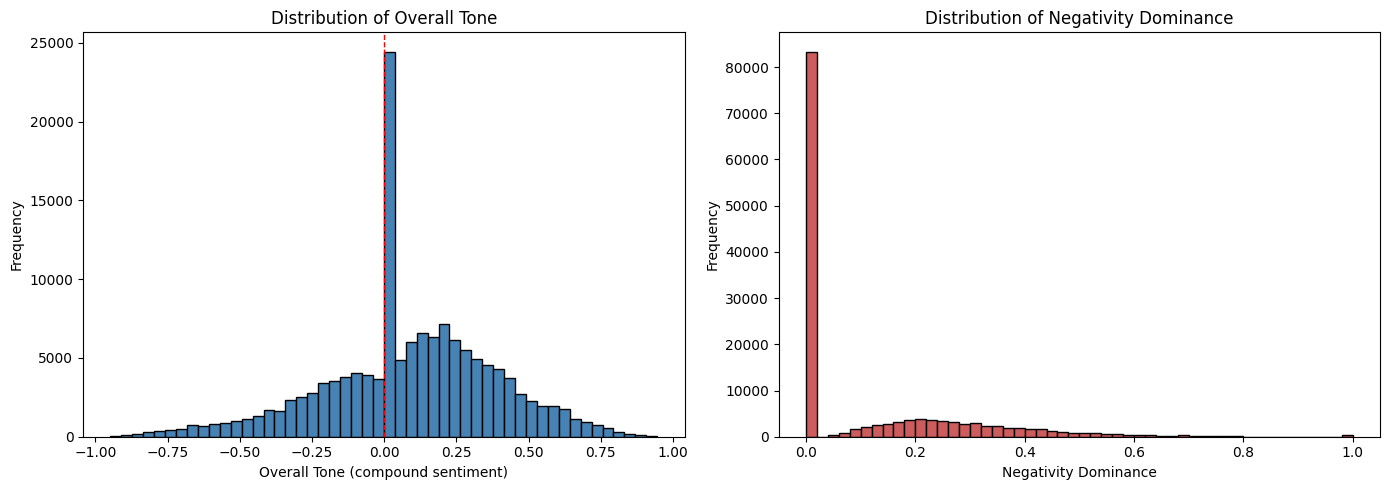

In [114]:
# plotting histogram
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['overall_tone'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Overall Tone')
axes[0].set_xlabel('Overall Tone (compound sentiment)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)

axes[1].hist(df['negativity_dominance'], bins=50, color='indianred', edgecolor='black')
axes[1].set_title('Distribution of Negativity Dominance')
axes[1].set_xlabel('Negativity Dominance')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig("histograms.png",dpi=150)
plt.show()

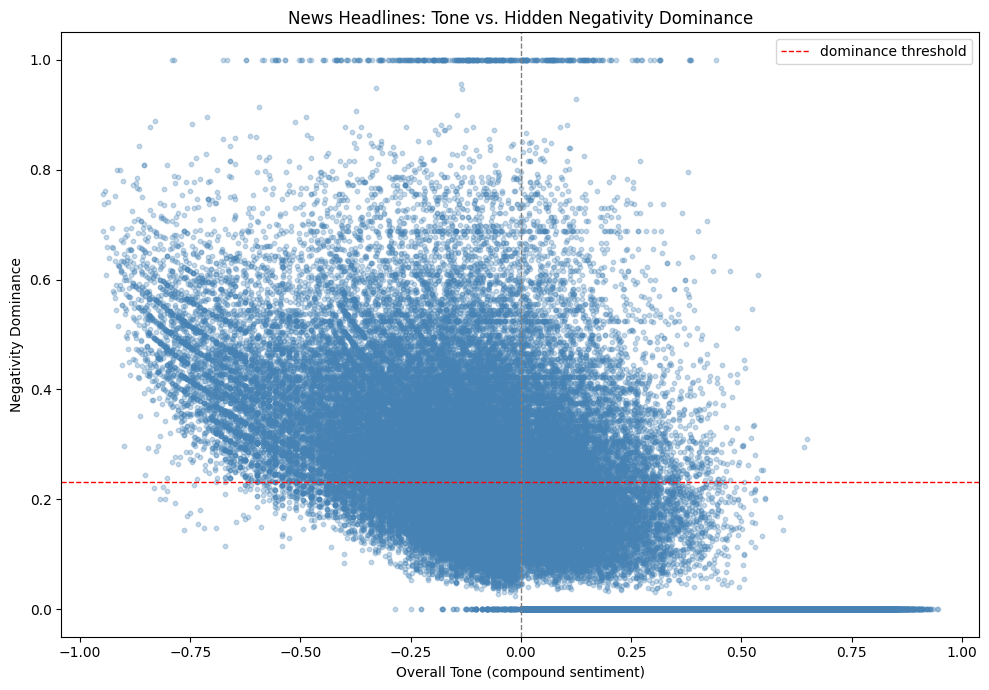

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(df['overall_tone'], df['negativity_dominance'],
            alpha=0.3, s=10, color='steelblue')

plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(df['negativity_dominance'].median() if df['negativity_dominance'].median() > 0
            else df['negativity_dominance'].quantile(0.75),
            color='red', linestyle='--', linewidth=1, label='dominance threshold')

plt.xlabel('Overall Tone (compound sentiment)')
plt.ylabel('Negativity Dominance')
plt.title('News Headlines: Tone vs. Hidden Negativity Dominance')
plt.legend()
plt.tight_layout()
plt.savefig('quadrant_plot.png', dpi=150)
plt.show()

In [116]:
# now testing it on longer documents
# to see how it is working

long_test_article = """
The city council unanimously approved the new downtown revitalization plan on Tuesday.
Local business owners expressed optimism about increased foot traffic in the coming months.
The plan includes new bike lanes, expanded public seating, and updated street lighting.
However, three small businesses have already been forced to close due to rising rents in the area.
One longtime shop owner said she felt abandoned by the very city she had supported for two decades.
Community advocates warned that without rent protections, the revitalization could displace the same residents it claims to help.
Despite these concerns, city officials say the project remains on schedule for a spring opening.
Mayor Torres called the plan "a turning point" for the neighborhood's economic future.
Critics argue the mayor's optimism ignores the human cost of rapid redevelopment.
Public hearings on the displacement concerns are scheduled for next month.
"""

test_sentences = sent_tokenize(long_test_article)
print(f"Number of sentences: {len(test_sentences)}")
print(negativity_dominance_scoring(test_sentences))

Number of sentences: 10
(0.03227, 0.368)


In [118]:
# now testing with two line sentence
# because max_neg works well in short description news text (2-3 lines)
test_sentences_2 = [
    "Local school celebrates record graduation rates this year.",
    "The celebration was overshadowed by outrage and heartbreak after brutal layoffs devastated the teaching staff."
]

print(negativity_dominance_scoring(test_sentences_2))

(-0.18615000000000004, 0.579)


In [119]:
test_sentences_3 = [
    "The charity gala raised a record $2 million for local families.",
    "Organizers held a moment of silence for a volunteer who died in a car crash the night before."
]

print(negativity_dominance_scoring(test_sentences_3))

(-0.16075, 0.326)


In [120]:
test_sentences_4 = [
    "Despite early fears of disaster, the surgery was a complete success.",
    "The patient is fully recovered and back home with family."
]

print(negativity_dominance_scoring(test_sentences_4))

(0.117, 0)
